# Text Analytics 2023-2024 - 4th mini-lab


## Topics Covered

* Text to word embeddings conversion
* Introduction to CNNs for text classification with Keras (TensorFlow backend)
* Multi-filtered CNNs for text classification

## Install Tensorflow (w/ Keras) and fasttext


In [ ]:
%%capture
!pip install -U tensorflow
!pip install -U fasttext

## **Load dataset**

The Reuters Corpus contains 10,788 news documents totaling 1.3 million words. The documents have been classified into 90 (possibly overlapping) topics, and grouped into two sets, called "training" and "test".

https://www.nltk.org/book/ch02.html

Categories in the Reuters corpus may overlap with each other, simply because a news story often covers multiple topics.

In [ ]:
!python3 -m nltk.downloader reuters;
!unzip /root/nltk_data/corpora/reuters.zip -d /root/nltk_data/corpora;

In [ ]:
# Load reuter's documents and labels
import nltk

from nltk.corpus import reuters
from sklearn.preprocessing import MultiLabelBinarizer # Used for multilabel classification problem
from sklearn.model_selection import train_test_split


mlb = MultiLabelBinarizer()

documents = reuters.fileids()
test = [d for d in documents if d.startswith('test/')]
train = [d for d in documents if d.startswith('training/')]

X = [reuters.raw(doc_id) for doc_id in train]
y = mlb.fit_transform([reuters.categories(doc_id) for doc_id in train])
X_train, X_dev, y_train, y_dev = train_test_split(X, y, test_size=0.3,
                                                  random_state=12547392)

X_test = [reuters.raw(doc_id) for doc_id in test]
y_test = mlb.transform([reuters.categories(doc_id) for doc_id in test])

In [ ]:
print(len(X_train))
print(len(X_dev))
print(len(X_test))

5438
2331
3019


In [ ]:
print(y_train[0])
print(X_train[0])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
BARUCH-FOSTER CORP &lt;BFO> 4TH QTR LOSS
  Shr loss 92 cts vs profit one ct
      Net loss 2,487,439 vs profit 48,709
      Revs 1,788,141 vs 4,167,070
      Year
      Shr loss 1.50 dlrs vs profit 48 cts
      Net loss 4,073,724 vs profit 1,309,412
      Revs 8,193,455 vs 15.7 mln
      NOTE: 1986 year net includes 3,095,305 dlr writedown of oil
  properties and reserves.
  




## Download and unzip fasttext binary model for English word embeddings

In [ ]:
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.bin.gz
!gzip -d cc.en.300.bin.gz

--2024-02-20 09:11:30--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.bin.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 52.84.251.114, 52.84.251.15, 52.84.251.27, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|52.84.251.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4503593528 (4.2G) [application/octet-stream]
Saving to: ‘cc.en.300.bin.gz’

cc.en.300.bin.gz    100%[===================>]   4.19G   138MB/s    in 24s     

2024-02-20 09:11:55 (177 MB/s) - ‘cc.en.300.bin.gz’ saved [4503593528/4503593528]



## Tokenize, convert text (sequence of words) to sequence of indices and PAD the sequences

In [ ]:
import tensorflow as tf

MAX_WORDS = 100000
MAX_SEQUENCE_LENGTH = 250
EMBEDDING_DIM = 300

vectorizer = tf.keras.layers.TextVectorization(max_tokens=MAX_WORDS,
                                               output_mode='int', ngrams=1,
                                               output_sequence_length=MAX_SEQUENCE_LENGTH)

vectorizer.adapt(X_train)

In [ ]:
print('Found %s unique tokens.' % len(vectorizer.get_vocabulary()))

Found 33574 unique tokens.


In [ ]:
vectorizer.get_vocabulary()[:10]

['', '[UNK]', 'the', 'to', 'of', 'in', 'said', 'and', 'a', 'mln']

## Initialize embedding matrix with fasttext pre-trained embedings

In [ ]:
import fasttext
import numpy as np

fasttext_model = fasttext.load_model('cc.en.300.bin')
embedding_matrix = np.zeros(shape=(MAX_WORDS, EMBEDDING_DIM))

for w2idx, _word in enumerate(vectorizer.get_vocabulary()):
    # Skip PAD and UNK tokens
    if w2idx >= 2:
      embedding_matrix[w2idx] = fasttext_model.get_word_vector(_word)

del fasttext_model

## CNNs for text classification
CNNs are employed over word sequences in three modes:

- Valid (No padding): a representation per n-gram.
- Same (Padding so that the output size is the same as the input size): a representation per token (timestep).
- Causal (Padding-Dilation): a representation per token applying dilated CNNs.

  https://theblog.github.io/post/convolution-in-autoregressive-neural-networks/
  
Like RNNs, CNNs are usually followed by a pooling mechanism in order to produce a fixed-size sequence representation:

- Use a pooling mechanism over time (e.g., MaxPooling, MeanPooling)
- Use self-attention mechanisms.

## Stacked CNNs followed by Max-Pooling


In [ ]:
import tensorflow.keras.backend as K

def recall(y_true, y_pred):

    """
    Recall metric.
    Only computes a batch-wise average of recall.
    Computes the recall, a metric for multi-label classification of
    how many relevant items are selected.
    """
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall


def precision(y_true, y_pred):

    """
    Precision metric.
    Only computes a batch-wise average of precision.
    Computes the precision, a metric for multi-label classification of
    how many selected items are relevant.
    Source
    ------
    https://github.com/fchollet/keras/issues/5400#issuecomment-314747992
    """
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision


def f1(y_true, y_pred):

    """Calculate the F1 score."""
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * ((p * r) / (p + r))


def accuracy(y_true, y_pred):
    return K.mean(K.equal(y_true, K.round(y_pred)), axis=1)

In [ ]:
# Create and train a CNN model with trigram filters
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


FILTERS = 128  # the dimensionality of the output space (i.e. the number of output filters in the convolution)
KERNEL = 3  # the length of the 1D convolution window
DENSE = 64
N_CLASSES = 90

# create empty sequential model
model = tf.keras.Sequential()
model.add(tf.keras.Input(shape=(1,), dtype=tf.string))
model.add(vectorizer)  # string to int!
# add an embedding layer
model.add(tf.keras.layers.Embedding(input_dim=MAX_WORDS, # Size of the vocabulary, i.e. maximum integer index + 1
                                    output_dim=EMBEDDING_DIM,
                                    weights=[embedding_matrix],
                                    input_length=MAX_SEQUENCE_LENGTH,
                                    mask_zero=True,
                                    trainable=False))
# add 0.2 dropout probabillity
model.add(tf.keras.layers.Dropout(0.2))
# add a stack of convolution layers
model.add(tf.keras.layers.Conv1D(filters=FILTERS, kernel_size=KERNEL,
                                 activation='relu', padding='valid'))
model.add(tf.keras.layers.Conv1D(filters=FILTERS, kernel_size=KERNEL,
                                 activation='relu', padding='valid'))
model.add(tf.keras.layers.Conv1D(filters=FILTERS, kernel_size=KERNEL,
                                 activation='relu', padding='valid'))
model.add(tf.keras.layers.Conv1D(filters=FILTERS, kernel_size=KERNEL,
                                 activation='relu', padding='valid'))
model.add(tf.keras.layers.Conv1D(filters=FILTERS, kernel_size=KERNEL,
                                 activation='relu', padding='valid'))
# max pooling
model.add(tf.keras.layers.GlobalMaxPooling1D())
# add 0.2 dropout probabillity
model.add(tf.keras.layers.Dropout(0.2))
# add dense layer
model.add(tf.keras.layers.Dense(DENSE, activation='relu'))
# add final linear layer
model.add(tf.keras.layers.Dense(N_CLASSES, activation='sigmoid'))

print(model.summary())
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=[precision, recall, f1, accuracy])
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    '/content/checkpoints/keras_CNN_model', monitor='val_f1', verbose=1,
    save_best_only=True, mode='max'
    )
history = model.fit(np.array(X_train), y_train,
              batch_size=32,
              epochs=15,
              verbose = 0,
              callbacks=[checkpoint],
              validation_data=(np.array(X_dev), y_dev),
              shuffle=True)

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization (TextVe  (None, 250)               0         
 ctorization)                                                    
                                                                 
 embedding_8 (Embedding)     (None, 250, 300)          30000000  
                                                                 
 dropout_16 (Dropout)        (None, 250, 300)          0         
                                                                 
 conv1d_25 (Conv1D)          (None, 248, 128)          115328    
                                                                 
 conv1d_26 (Conv1D)          (None, 246, 128)          49280     
                                                                 
 conv1d_27 (Conv1D)          (None, 244, 128)          49280     
                                                      

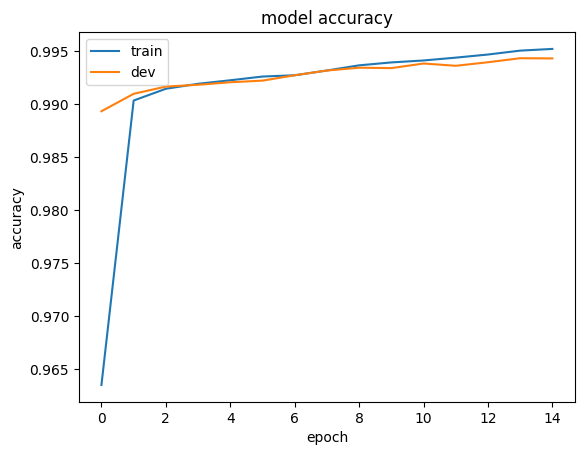

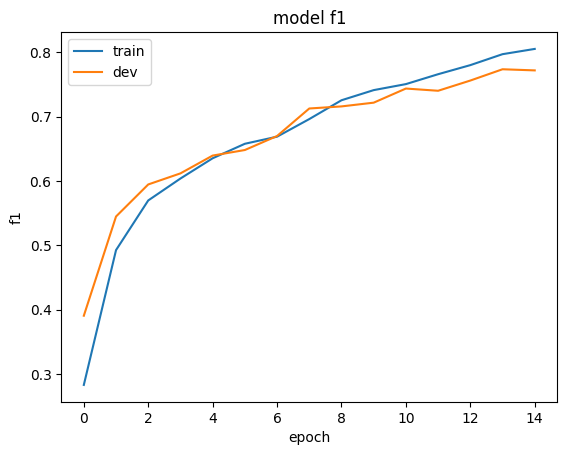

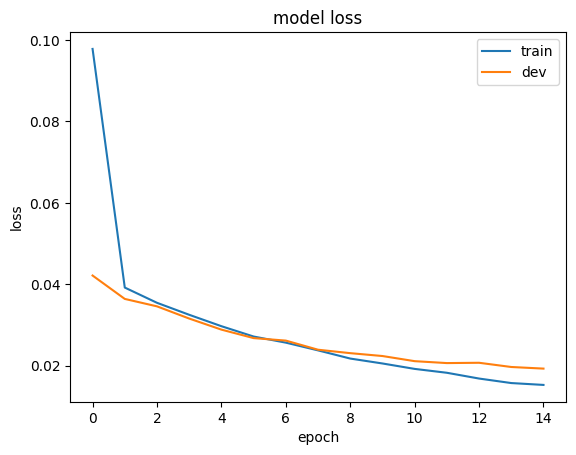

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'dev'], loc='upper left')
plt.show()

# summarize history for f1
plt.plot(history.history['f1'])
plt.plot(history.history['val_f1'])
plt.title('model f1')
plt.ylabel('f1')
plt.xlabel('epoch')
plt.legend(['train', 'dev'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'dev'], loc='upper right')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def predict_data(data):
    T = model.predict(data)
    # T2 = np.zeros_like(T)
    # for i in range(T.shape[0]):
    #   T2[i] = T[i]/np.max(T[i])
    C = np.ones((T.shape[1],)) / 2
    T = (C<=T)
    return T*1


print(f'Dev accuracy: {accuracy_score(y_dev, predict_data(X_dev))*100:.2f}%')
print(f'Dev micro-f1: {f1_score(y_dev, predict_data(X_dev), average="micro")*100:.2f}%')
print(f'Test accuracy: {accuracy_score(y_test, predict_data(X_test))*100:.2f}%')
print(f'Test micro-f1: {f1_score(y_test, predict_data(X_test), average="micro")*100:.2f}%')

73/73 [==============================] - 1s 6ms/step
Dev accuracy: 67.74%
73/73 [==============================] - 0s 6ms/step
Dev micro-f1: 77.02%
95/95 [==============================] - 1s 5ms/step
Test accuracy: 69.92%
95/95 [==============================] - 1s 5ms/step
Test micro-f1: 77.01%


### **Multi-filter CNN**


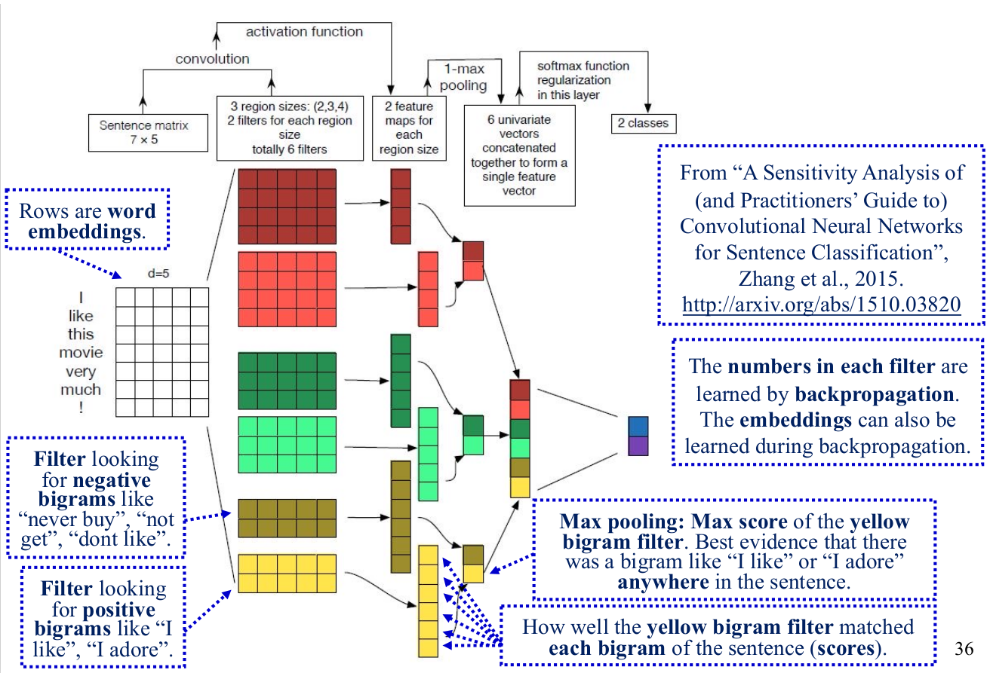

In [ ]:
from IPython.display import Image
Image('Multi_filter_CNN.png')

In [ ]:
#Create and train a CNN model with (2,3,4)-gram filters using Keras functional API

FILTERS = 128  # the dimensionality of the output space (i.e. the number of output filters in the convolution)
DENSE = 256
N_CLASSES = 90


inputs = tf.keras.Input(shape=(1,), dtype=tf.string)
x = vectorizer(inputs)
# Embeddings
embeddings = tf.keras.layers.Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM,
                                       weights=[embedding_matrix],
                                       input_length=MAX_SEQUENCE_LENGTH,
                                       trainable=False)(x)
# Dropout over Embeddings
dropped_embeddings = tf.keras.layers.Dropout(rate=0.2)(embeddings)
# Multi-filter CNNs
pooled_convs = []
filter_sizes = [2, 3, 4]

for n_gram in filter_sizes:
    # n-gram convolutions with padding
    convs = tf.keras.layers.Conv1D(
        filters=FILTERS, kernel_size=n_gram,
        strides=1, padding="same", activation='relu',
        name='{}-gram_Convolutions'.format(n_gram))(dropped_embeddings)
    # Max-Pooling over time
    pooled_convs.append(
        tf.keras.layers.GlobalMaxPooling1D(
            name='{}-gram_MaxPool'.format(n_gram))(convs)
        )
# Concatenation of filters form all window sizes
concat =  tf.keras.layers.concatenate(pooled_convs)
concat = tf.keras.layers.Dropout(rate=0.5)(concat)
outputs = tf.keras.layers.Dense(N_CLASSES, activation='sigmoid')(concat)
model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=[precision, recall, f1, accuracy])

print(model.summary())
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    '/content/checkpoints/keras_Deep_CNN_model',
    monitor='val_f1', verbose=1, save_best_only=True, mode='max')
history2 = model.fit(np.array(X_train),
                     y_train,
                     batch_size=32,
                     epochs=15,
                     verbose = 0,
                     callbacks=[checkpoint],
                     validation_data=(np.array(X_dev), y_dev),
                     shuffle=True)

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_7 (InputLayer)        [(None, 1)]                  0         []                            
                                                                                                  
 text_vectorization (TextVe  (None, 250)                  0         ['input_7[0][0]']             
 ctorization)                                                                                     
                                                                                                  
 embedding_9 (Embedding)     (None, 250, 300)             3000000   ['text_vectorization[4][0]']  
                                                          0                                       
                                                                                            

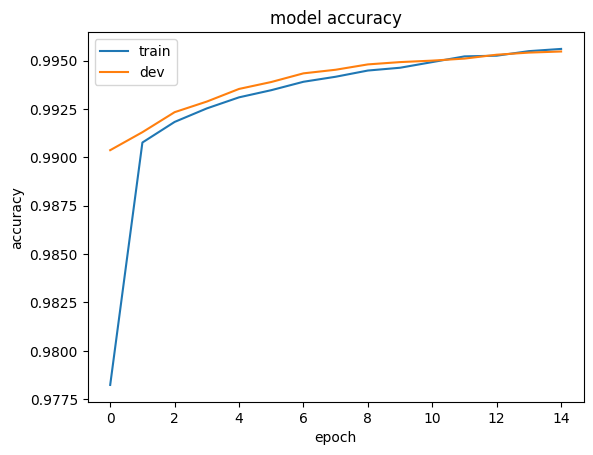

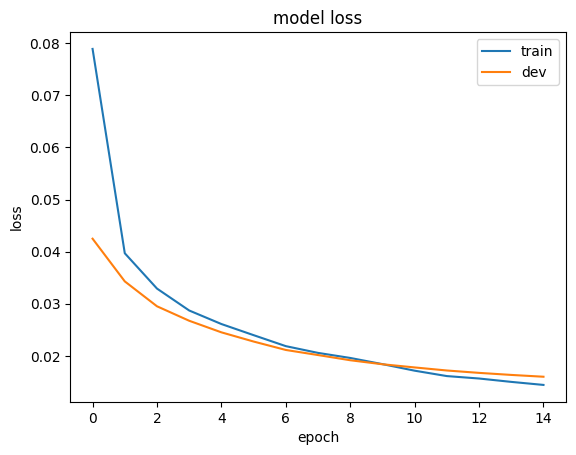

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

# summarize history for accuracy
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'dev'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'dev'], loc='upper right')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def predict_data(data):
    T = model.predict(data)
    # T2 = np.zeros_like(T)
    # for i in range(T.shape[0]):
    #   T2[i] = T[i]/np.max(T[i])
    C = np.ones((T.shape[1],)) / 2
    T = (C<=T)
    return T*1


print(f'Dev accuracy: {accuracy_score(y_dev, predict_data(X_dev))*100:.2f}%')
print(f'Dev micro-f1: {f1_score(y_dev, predict_data(X_dev), average="micro")*100:.2f}%')
print(f'Test accuracy: {accuracy_score(y_test, predict_data(X_test))*100:.2f}%')
print(f'Test micro-f1: {f1_score(y_test, predict_data(X_test), average="micro")*100:.2f}%')

73/73 [==============================] - 1s 7ms/step
Dev accuracy: 72.42%
73/73 [==============================] - 0s 6ms/step
Dev micro-f1: 81.93%
95/95 [==============================] - 1s 6ms/step
Test accuracy: 74.40%
95/95 [==============================] - 1s 5ms/step
Test micro-f1: 81.67%


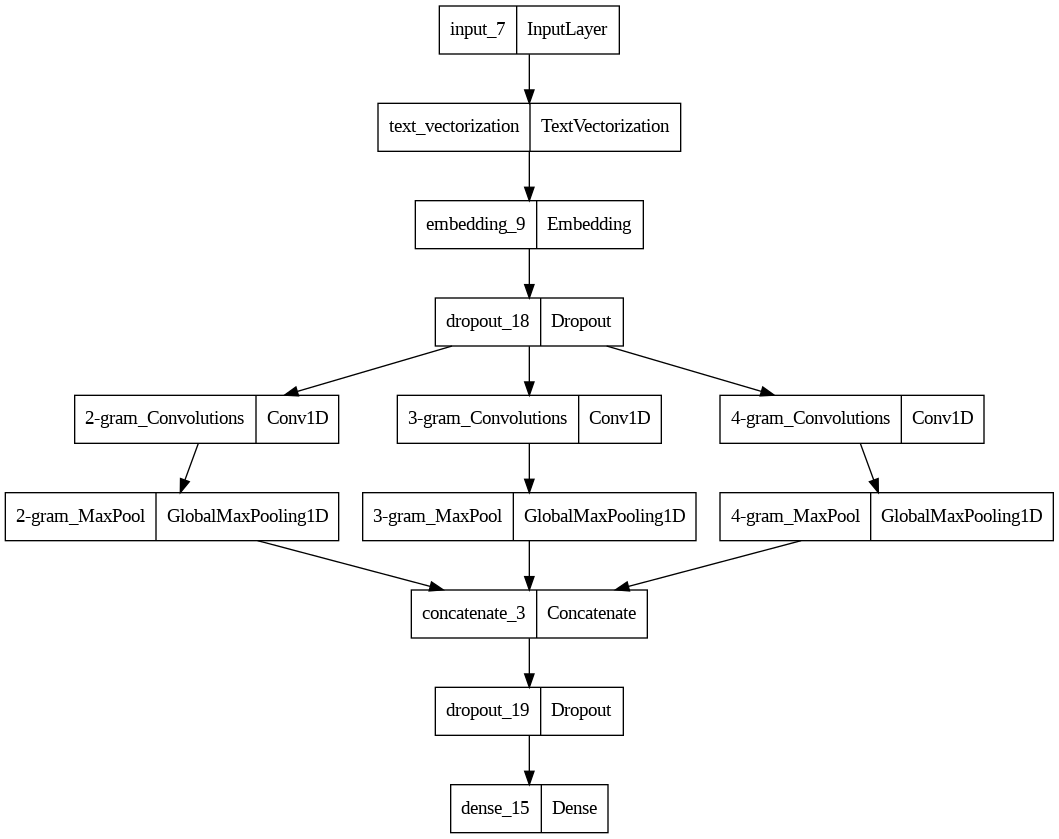

In [ ]:
%matplotlib notebook

from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model.png')

from IPython.display import Image
Image('model.png')